# **Grad-CAM implementation for YOLOv8**

```bash
Image → YOLO detects → Grad-CAM explains → overlay
```

## STEP 1: Grad-CAM class definition

In [1]:
import torch

class YOLOv8GradCAM:
    def __init__(self, target_layer):
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output

        self.target_layer.register_forward_hook(forward_hook)

    def generate_cam(self):
        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.squeeze().detach().cpu().numpy()

## STEP 2: Load Model

In [2]:
from ultralytics import YOLO

model = YOLO("runs\detect\saved_runs\detect_v1\weights\last.pt")

# 🔑 IMPORTANT: hook NECK, not detect head
target_layer = model.model.model[20]

cam = YOLOv8GradCAM(target_layer)

## STEP 3: Prepare an Image

In [ ]:
import cv2
import numpy as np

img_path = "PIDray_YOLO/images/val/xray_00012.png"

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (640, 640))

img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float()
img_tensor = img_tensor.unsqueeze(0) / 255.0 

device = next(model.model.parameters()).device
img_tensor = img_tensor.to(device=device)
model.model.model.to(device)

Sequential(
  (0): Conv(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
  )
  (2): C2f(
    (cv1): Conv(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1))
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
      )
    )
  )
  (3): Conv(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
  )

## STEP 4: Detection + Grad-CAM

In [6]:
model.model.eval()
model.model.zero_grad()

img_tensor.requires_grad_(True)

with torch.enable_grad():

    # detection (for boxes)
    results = model(img_path)

    # forward pass (for CAM)
    _ = model.model(img_tensor)

    activations = cam.activations
    target_score = activations.mean()

    # 🔑 compute gradients manually
    grads = torch.autograd.grad(
        outputs=target_score,
        inputs=activations,
        retain_graph=True
    )[0]

    cam.gradients = grads

    cam_map = cam.generate_cam()


image 1/1 c:\Hadee\Programs\baggage-threat-scanner\PIDray_YOLO\images\val\xray_00167.png: 576x640 2 Batons, 69.6ms
Speed: 4.8ms preprocess, 69.6ms inference, 2.0ms postprocess per image at shape (1, 3, 576, 640)


## STEP 5 — Overlay CAM

(np.float64(-0.5), np.float64(499.5), np.float64(447.5), np.float64(-0.5))

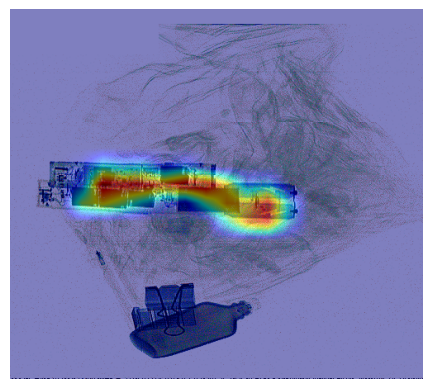

In [7]:
import matplotlib.pyplot as plt

def overlay_heatmap(image, cam_map, alpha=0.5):
    cam_map = cv2.resize(cam_map, (image.shape[1], image.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = heatmap * alpha + image * (1 - alpha)
    return overlay.astype(np.uint8)

overlayed = overlay_heatmap(img_rgb, cam_map)

plt.imshow(overlayed)
plt.axis("off")

## STEP 6: Per-object CAM

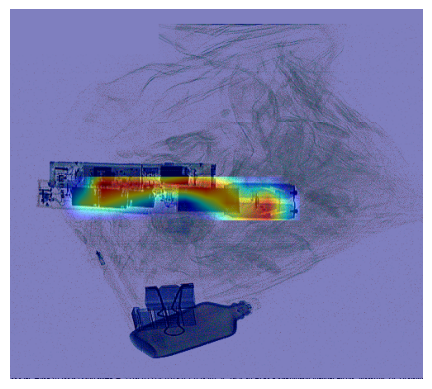

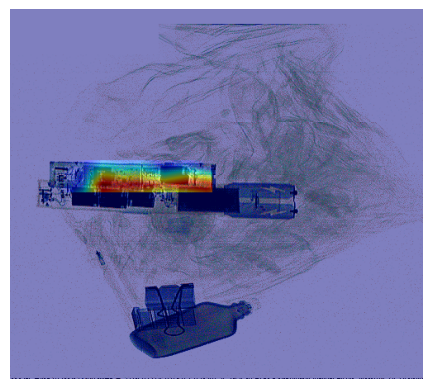

In [8]:
cam_resized = cv2.resize(cam_map, (img_rgb.shape[1], img_rgb.shape[0]))

boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)

for box in boxes:
    x1, y1, x2, y2 = box

    mask = np.zeros_like(cam_resized)
    mask[y1:y2, x1:x2] = cam_resized[y1:y2, x1:x2]

    overlayed = overlay_heatmap(img_rgb, mask)

    plt.imshow(overlayed)
    plt.axis("off")
    plt.show()

## STEP 7: Draw boxes + labels + CAM (combined)

In [ ]:
import cv2

img_vis = img_rgb.copy()

cam_resized = cv2.resize(cam_map, (img_rgb.shape[1], img_rgb.shape[0]))

boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
classes = results[0].boxes.cls.cpu().numpy()
scores = results[0].boxes.conf.cpu().numpy()

class_names = model.names  # YOLO class names

for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box
    cls_id = int(classes[i])
    score = scores[i]

    label = f"{class_names[cls_id]} ({score:.2f})"

    # 🔥 CAM mask for THIS object
    mask = np.zeros_like(cam_resized)
    mask[y1:y2, x1:x2] = cam_resized[y1:y2, x1:x2]

    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_vis = (0.6 * img_vis + 0.4 * heatmap).astype(np.uint8)

    # 🔴 Bounding box
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # # 🏷️ Label
    # cv2.putText(img_vis, label, (x1, y1 - 10),
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)


## STEP 8: Explanation Presets 

In [10]:
def get_explanation(class_name):
    explanations = {
        "Baton": "elongated dense metallic object",
        "Knife": "sharp edged high-density object",
        "Gun": "compact dense mechanical structure",
        "Wrench": "irregular metallic tool shape"
    }
    return explanations.get(class_name, "suspicious dense object")

In [11]:
explanation = get_explanation(class_names[cls_id])

cv2.putText(img_vis, explanation,
            (x1, y2 + 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2)

array([[[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       ...,

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 83,  69, 135],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [  0,   0,  81],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [  0,   0,  81]]

## STEP 9: Clean Display

(np.float64(-0.5), np.float64(499.5), np.float64(447.5), np.float64(-0.5))

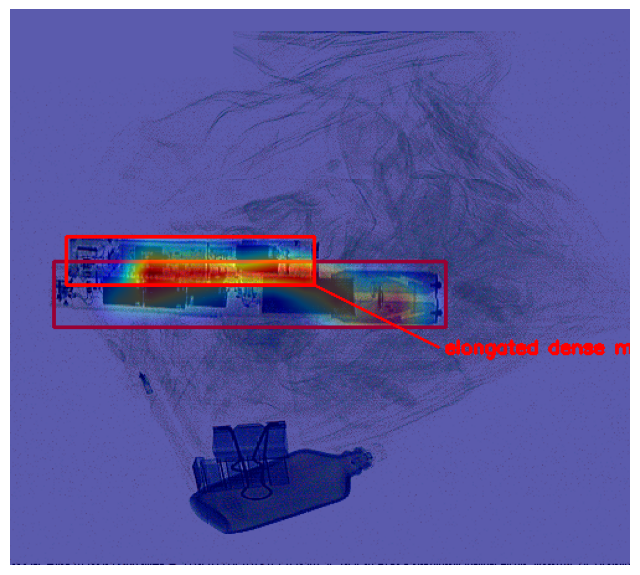

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(img_vis)
plt.axis("off")

In [18]:
cv2.line(img_vis, (x2, y2), (x2+100, y2+50), (255,0,0), 2)

cv2.putText(img_vis, explanation,
            (x2+105, y2+55),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            2)

array([[[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       ...,

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [ 91,  91, 173],
        ...,
        [ 91,  91, 173],
        [ 83,  69, 135],
        [ 91,  91, 173]],

       [[ 91,  91, 173],
        [ 91,  91, 173],
        [  0,   0,  81],
        ...,
        [ 91,  91, 173],
        [ 91,  91, 173],
        [  0,   0,  81]]